In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
data_dir = '../datasets/EuroSAT_RGB/'
label_names = sorted(os.listdir(data_dir))
label_names.remove('.DS_Store')
label_names

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [4]:
# count number of images per class
class_counts = {label: len(os.listdir(os.path.join(data_dir, label))) for label in label_names}
class_counts

{'AnnualCrop': 3000,
 'Forest': 3000,
 'HerbaceousVegetation': 3000,
 'Highway': 2500,
 'Industrial': 2500,
 'Pasture': 2000,
 'PermanentCrop': 2500,
 'Residential': 3000,
 'River': 2500,
 'SeaLake': 3000}

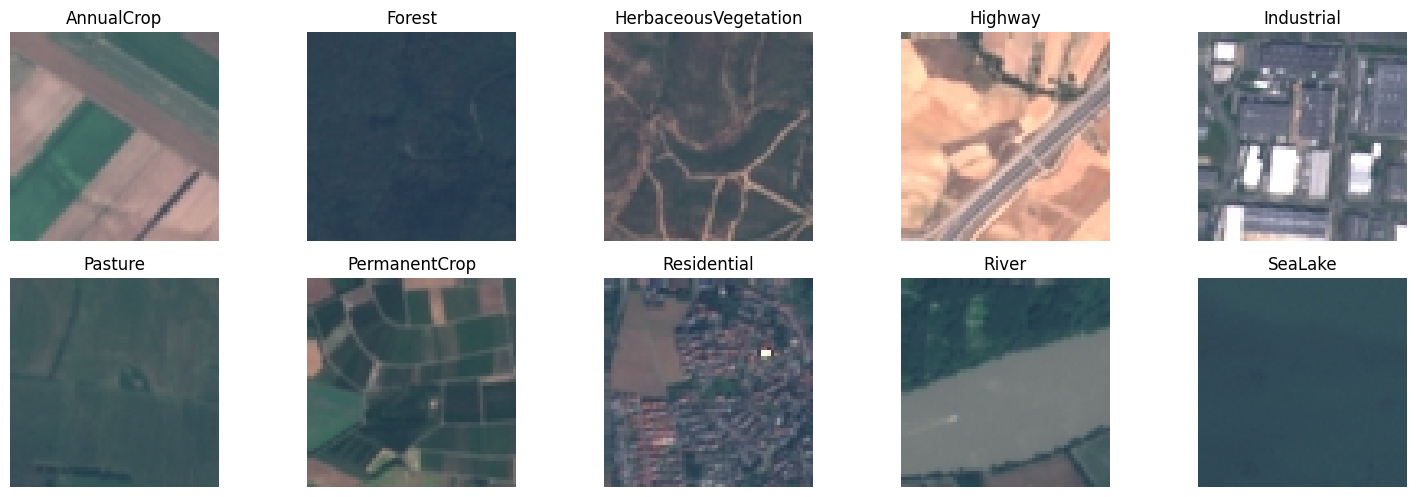

In [5]:
plt.figure(figsize=(15, 10))
for i, label in enumerate(label_names):
    filename = os.listdir(os.path.join(data_dir, label))[0]
    path = os.path.join(data_dir, label, filename)
    img = Image.open(path)
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')
    
plt.tight_layout()
plt.show()

## visualize R, G, B

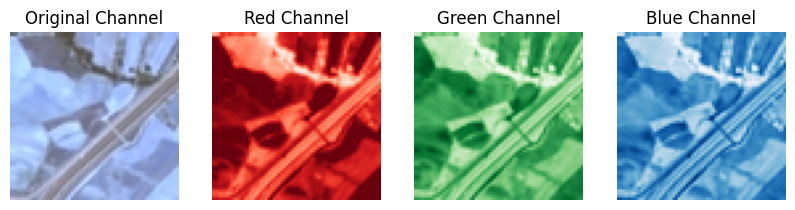

In [6]:
label = label_names[3]
path = os.path.join(data_dir, label, os.listdir(os.path.join(data_dir, label))[0])

img = cv2.imread(path)
B, G, R = cv2.split(img)
titles = ["Original", "Red", "Green", "Blue"]
cmaps = [None, "Reds", "Greens", "Blues"]

# plot the RGB channels
plt.figure(figsize=(10, 6))
for img, color, i in zip([img, R, G, B], ['Original', 'Red', 'Green', 'Blue'], range(4)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap=cmaps[i])
    plt.title(f'{color} Channel')
    plt.axis('off')

### feature engineering

In [7]:
def compute_stats(path_label):
    path, label = path_label
    
    img = cv2.imread(path)
    if img is None:
        return None  # skip bad images

    stats = {}
    for i, color in enumerate(['Blue', 'Green', 'Red']):
        channel = img[:, :, i]
        stats[f'{color}_mean'] = channel.mean()
        stats[f'{color}_std'] = channel.std()
        stats[f'{color}_min'] = channel.min()
        stats[f'{color}_max'] = channel.max()
    
    img_num = os.path.basename(path).split("_")[1].split('.')[0]

    return {
        'image_id': img_num,
        'label': label,
        **stats
    }

In [8]:
# Build list of (path, label)
paths = [
    (os.path.join(data_dir, label, fname), label)
    for label in label_names
    for fname in os.listdir(os.path.join(data_dir, label))
]

# Apply map
data_stats = list(filter(None, map(compute_stats, paths)))

In [9]:
df = pd.DataFrame(data_stats)
df.set_index('image_id', inplace=True)
df.head()

,label,Blue_mean,Blue_std,Blue_min,Blue_max,Green_mean,Green_std,Green_min,Green_max,Red_mean,Red_std,Red_min,Red_max
image_id,,,,,,,,,,,,,
1414,AnnualCrop,119.371338,18.565473,82,163,121.351807,19.385658,73,169,119.488525,42.637695,57,207
1372,AnnualCrop,110.764893,22.730603,76,199,113.476807,25.915916,73,215,115.563721,44.279462,47,253
1366,AnnualCrop,126.442627,22.481973,82,180,136.837646,32.941343,85,204,172.473633,64.115883,68,255
2109,AnnualCrop,138.062256,26.238712,81,214,147.759766,31.589846,79,239,169.530762,43.727902,55,255
1400,AnnualCrop,127.583740,16.045508,70,162,135.745605,20.519028,65,180,172.199707,33.379157,55,240


In [10]:
map_labels2idx = {label: idx for idx, label in enumerate(label_names)}
map_idx2labels = {idx: label for label, idx in map_labels2idx.items()}
map_labels2idx, map_idx2labels

({'AnnualCrop': 0,
  'Forest': 1,
  'HerbaceousVegetation': 2,
  'Highway': 3,
  'Industrial': 4,
  'Pasture': 5,
  'PermanentCrop': 6,
  'Residential': 7,
  'River': 8,
  'SeaLake': 9},
 {0: 'AnnualCrop',
  1: 'Forest',
  2: 'HerbaceousVegetation',
  3: 'Highway',
  4: 'Industrial',
  5: 'Pasture',
  6: 'PermanentCrop',
  7: 'Residential',
  8: 'River',
  9: 'SeaLake'})

In [11]:
df["label_idx"] = df["label"].map(map_labels2idx)
df.head()

,label,Blue_mean,Blue_std,Blue_min,Blue_max,Green_mean,Green_std,Green_min,Green_max,Red_mean,Red_std,Red_min,Red_max,label_idx
image_id,,,,,,,,,,,,,,
1414,AnnualCrop,119.371338,18.565473,82,163,121.351807,19.385658,73,169,119.488525,42.637695,57,207,0
1372,AnnualCrop,110.764893,22.730603,76,199,113.476807,25.915916,73,215,115.563721,44.279462,47,253,0
1366,AnnualCrop,126.442627,22.481973,82,180,136.837646,32.941343,85,204,172.473633,64.115883,68,255,0
2109,AnnualCrop,138.062256,26.238712,81,214,147.759766,31.589846,79,239,169.530762,43.727902,55,255,0
1400,AnnualCrop,127.583740,16.045508,70,162,135.745605,20.519028,65,180,172.199707,33.379157,55,240,0


In [ ]:
# Prepare data for stratified split
X = df[df.columns.difference(['label','label_idx'])].values
y = df['label_idx'].values

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

hyp_param_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,  # stratified 5-fold cross-validation
    random_state=42,
    n_jobs=-1
)

hyp_param_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [14]:
print("Best Hyperparameters:", hyp_param_search.best_params_)
print("Best CV Score:", hyp_param_search.best_score_)

Best Hyperparameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}
Best CV Score: 0.8062037037037036


In [15]:
# Train final model with best hyperparameters
best_model = GradientBoostingClassifier(**hyp_param_search.best_params_, random_state=42)
best_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = best_model.predict(X_test)

                      precision    recall  f1-score   support

          AnnualCrop       0.85      0.83      0.84       600
              Forest       0.93      0.95      0.94       600
HerbaceousVegetation       0.81      0.79      0.80       600
             Highway       0.51      0.43      0.47       500
          Industrial       0.85      0.91      0.88       500
             Pasture       0.80      0.86      0.83       400
       PermanentCrop       0.69      0.71      0.70       500
         Residential       0.81      0.86      0.83       600
               River       0.68      0.68      0.68       500
             SeaLake       0.96      0.93      0.94       600

            accuracy                           0.80      5400
           macro avg       0.79      0.79      0.79      5400
        weighted avg       0.80      0.80      0.80      5400



array([[499,   3,   8,  15,   0,   7,  42,   1,  22,   3],
       [  0, 568,   5,   0,   0,  11,   0,   0,   4,  12],
       [  6,   4, 475,  11,  13,   9,  48,  15,  17,   2],
       [ 25,   2,  26, 215,  34,  17,  40,  57,  81,   3],
       [  0,   0,   2,  18, 453,   0,   1,  23,   3,   0],
       [  4,  16,   5,  10,   0, 345,   9,   1,   8,   2],
       [ 32,   0,  33,  33,   7,  18, 354,   9,  14,   0],
       [  0,   0,  16,  39,  20,   0,   6, 515,   3,   1],
       [ 21,   3,  12,  75,   4,  16,  12,  12, 342,   3],
       [  1,  15,   6,   2,   0,   7,   1,   1,   9, 558]])

In [17]:
report_results = classification_report(y_test, y_pred, target_names=label_names)
print(report_results) 

                      precision    recall  f1-score   support

          AnnualCrop       0.85      0.83      0.84       600
              Forest       0.93      0.95      0.94       600
HerbaceousVegetation       0.81      0.79      0.80       600
             Highway       0.51      0.43      0.47       500
          Industrial       0.85      0.91      0.88       500
             Pasture       0.80      0.86      0.83       400
       PermanentCrop       0.69      0.71      0.70       500
         Residential       0.81      0.86      0.83       600
               River       0.68      0.68      0.68       500
             SeaLake       0.96      0.93      0.94       600

            accuracy                           0.80      5400
           macro avg       0.79      0.79      0.79      5400
        weighted avg       0.80      0.80      0.80      5400



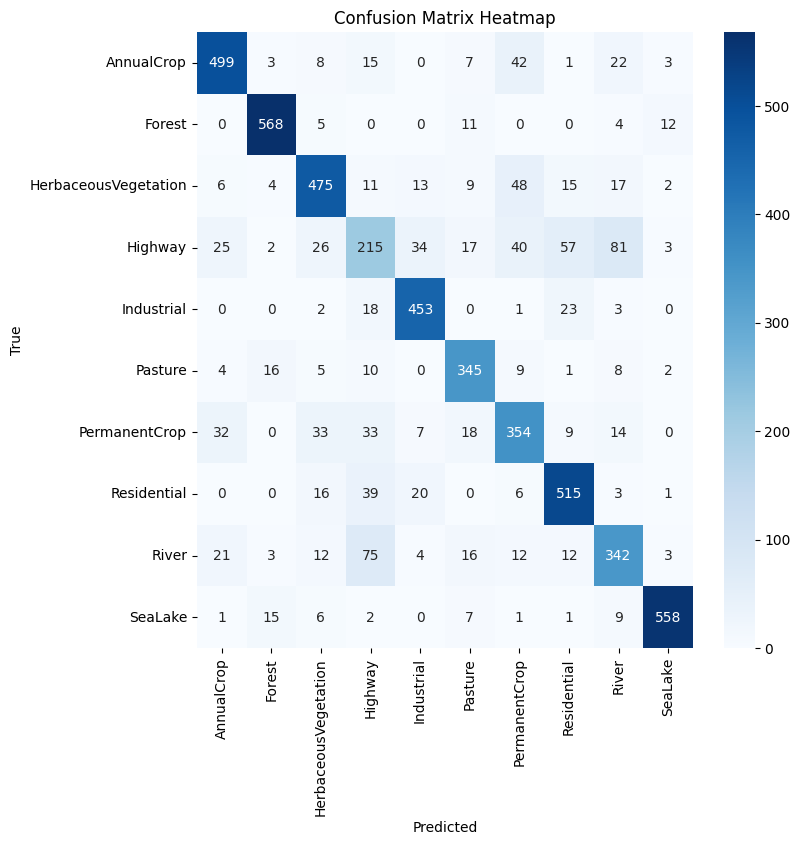

In [25]:
conf_mat_results = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(conf_mat_results, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

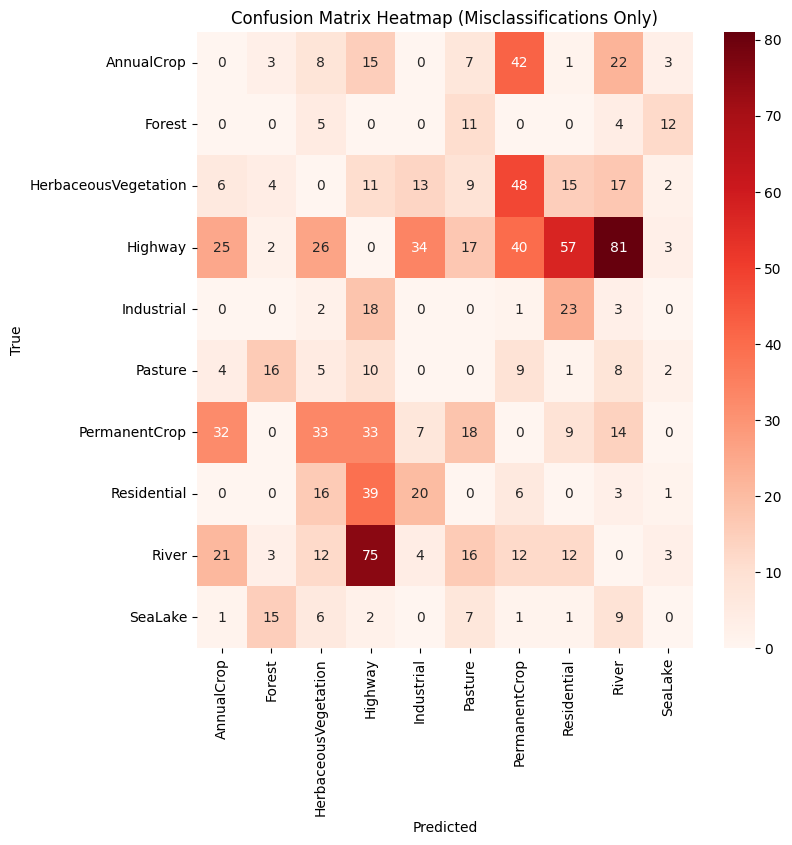

In [ ]:
import numpy as np

mask = np.eye(conf_mat_results.shape[0], dtype=bool)
conf_mat_masked = np.where(mask, 0, conf_mat_results)

# plot masked confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(conf_mat_masked, annot=True, fmt='d', cmap='Reds', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap (Misclassifications Only)')
plt.show()